# S5Mars semantic segmentation training

Self-contained Kaggle notebook for loading `Mirali33/mb-s5mars`, building PyTorch DataLoaders, training SegFormer-B0 with Hugging Face Transformers, evaluating segmentation metrics, saving checkpoints, and visualizing predictions.


In [78]:
!pip install -q datasets huggingface_hub transformers tqdm matplotlib segmentation-models-pytorch


In [79]:
HF_TOKEN = "HF_TOKEN_PLACEHOLDER"
REPO_ID = "Mirali33/mb-s5mars"
TRAIN_SPLIT = "train"
VAL_SPLIT = "val"
TEST_SPLIT = "test"

MODEL_NAME = "segformer_b0"  # [segformer_b0, unet_resnet34]
PRETRAINED_NAME = "nvidia/segformer-b0-finetuned-ade-512-512"
UNET_ENCODER_NAME = "resnet34"
UNET_ENCODER_WEIGHTS = "imagenet"

IMAGE_SIZE = (512, 512)
NUM_CLASSES = 9
IGNORE_INDEX = -100

EPOCHS = 30
BATCH_SIZE = 32
NUM_WORKERS = None  # None = choose dynamically from available CPU cores.
FREEZE = "none"  # [none, encoder, classifier]
LR = 1e-4
WEIGHT_DECAY = 0.01
WARMUP_EPOCHS = 1

CRITERION_NAME = "combined"  # [cross_entropy, generalized_dice, combined]
CRITERION_ALPHA = 0.5 # [1 for cross_entropy, 0 for generalized_dice]
CRITERION_WEIGHT_TYPE = "square"  # [uniform, simple, square]
CRITERION_SMOOTH = 1e-5

LIMIT_TRAIN_BATCHES = None
LIMIT_VAL_BATCHES = None
OUTPUT_DIR = f"/kaggle/working/{MODEL_NAME}_s5mars"


In [80]:
from huggingface_hub import HfApi, get_token, login, whoami
from huggingface_hub.utils import HfHubHTTPError

def is_hf_logged_in():
    global HF_TOKEN

    try:
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        HF_TOKEN = user_secrets.get_secret("hf_token")
        if HF_TOKEN:
            print("Detected Kaggle environment. HF Token loaded from Kaggle Secrets.")
    except ImportError:
        print("Kaggle environment not detected. No HF Token loaded automatically.")
    except Exception as exc:
        print(f"Could not load HF token from Kaggle Secrets: {exc}")

    if HF_TOKEN in (None, "", "HF_TOKEN_PLACEHOLDER"):
        HF_TOKEN = get_token()

    if HF_TOKEN in (None, "", "HF_TOKEN_PLACEHOLDER"):
        print("No HF token available. Continuing with unauthenticated access.")
        return False

    try:
        login(token=HF_TOKEN)
        user = whoami(token=HF_TOKEN)
        username = user.get("name", "unknown user")
        print(f"HF Login successful: {username}")
        return True
    except HfHubHTTPError:
        print("HF Login failed with the provided token. Continuing unauthenticated.")
        HF_TOKEN = None
        return False

HF_LOGGED_IN = is_hf_logged_in()


2026-07-06 11:34:30,973 | INFO | HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"


Detected Kaggle environment. HF Token loaded from Kaggle Secrets.


2026-07-06 11:34:31,061 | INFO | HTTP Request: GET https://huggingface.co/api/whoami-v2 "HTTP/1.1 200 OK"


HF Login successful: Dalphan


In [81]:
import json
import logging
import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import SegformerForSemanticSegmentation
import segmentation_models_pytorch as smp


def resolve_num_workers(configured_workers=None):
    if configured_workers is not None:
        return int(configured_workers)
    cpu_count = os.cpu_count() or 2
    return max(1, cpu_count)


NUM_WORKERS = resolve_num_workers(NUM_WORKERS)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("s5mars_segmentation_training")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_COUNT = torch.cuda.device_count()
DATA_PARALLEL_DEVICE_IDS = list(range(min(2, GPU_COUNT)))
USE_DATA_PARALLEL = len(DATA_PARALLEL_DEVICE_IDS) == 2

print("device", device)
print("available_gpus", GPU_COUNT)
print("data_parallel_device_ids", DATA_PARALLEL_DEVICE_IDS if USE_DATA_PARALLEL else [])
print("num_workers", NUM_WORKERS)


device cuda
available_gpus 2
data_parallel_device_ids [0, 1]
num_workers 4


In [82]:
CLASS_NAMES = {
    0: "Background",
    1: "Bedrock",
    2: "Hole",
    3: "Ridge",
    4: "Rock",
    5: "Rover",
    6: "Sand / Soil",
    7: "Sky",
    8: "Track",
}
PALETTE = {
    0: (30, 30, 30),
    1: (166, 118, 29),
    2: (0, 109, 119),
    3: (131, 56, 236),
    4: (230, 57, 70),
    5: (255, 183, 3),
    6: (42, 157, 143),
    7: (69, 123, 157),
    8: (244, 162, 97),
}
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


In [83]:
class SegmentationTransform:
    def __init__(self, size, normalize=True):
        self.size = size
        self.normalize = normalize

    def __call__(self, image, mask):
        image = image.resize((self.size[1], self.size[0]), Image.Resampling.BILINEAR)
        mask = mask.resize((self.size[1], self.size[0]), Image.Resampling.NEAREST)

        # Raw RGB image: [512, 512, 3].
        # Tensor image after transform: [3, 512, 512].
        # Batched image: [B, 3, 512, 512].
        image_tensor = torch.from_numpy(np.asarray(image, dtype=np.float32) / 255.0).permute(2, 0, 1).contiguous()
        if self.normalize:
            image_tensor = (image_tensor - MEAN) / STD

        # Raw mask: [512, 512].
        # Mask values are Mars-Bench class IDs: 0..8.
        # Class 0 is used as ignore_index.
        # Batched mask: [B, 512, 512].
        mask_array = np.asarray(mask, dtype=np.int64)
        if mask_array.ndim == 3:
            mask_array = mask_array[..., 0]
        mask_tensor = torch.from_numpy(mask_array).long()
        return image_tensor.float(), mask_tensor

def denormalize(image_tensor):
    return (image_tensor.cpu() * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

def colorize_mask(mask):
    mask = mask.cpu().numpy() if isinstance(mask, torch.Tensor) else np.asarray(mask)
    color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, rgb in PALETTE.items():
        color[mask == class_id] = rgb
    return color

def overlay(image, color_mask, alpha=0.45):
    base = (np.clip(image, 0, 1) * 255).astype(np.uint8)
    out = ((1 - alpha) * base + alpha * color_mask).astype(np.uint8)
    # background = np.all(color_mask == PALETTE[IGNORE_INDEX], axis=-1)
    # out[background] = base[background]
    return out

def add_class_legend(fig):
    handles = [
        Patch(
            facecolor=tuple(channel / 255 for channel in PALETTE[class_id]),
            edgecolor="black",
            label=f"{class_id}: {CLASS_NAMES[class_id]}",
        )
        for class_id in sorted(CLASS_NAMES)
    ]
    fig.legend(handles=handles, loc="center right", title="Classes", frameon=True)


In [84]:
class S5MarsHFDataset(Dataset):
    def __init__(self, repo_id, split, token=None, transform=None):
        token = None if token in (None, "", "HF_TOKEN_PLACEHOLDER") else token
        logger.info("Loading %s split=%s", repo_id, split)
        self.dataset = load_dataset(repo_id, split=split, token=token)
        self.transform = transform
        required = {"image", "mask", "width", "height", "class_labels"}
        missing = required - set(self.dataset.column_names)
        if missing:
            raise ValueError(f"Missing required columns: {sorted(missing)}")
        logger.info("Loaded dataset: repo=%s split=%s samples=%d columns=%s", repo_id, split, len(self.dataset), self.dataset.column_names)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        sample = self.dataset[index]
        image = sample["image"].convert("RGB")
        mask = sample["mask"].convert("L")
        image_tensor, mask_tensor = self.transform(image, mask)
        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "class_labels": list(sample["class_labels"]),
            "width": int(sample["width"]),
            "height": int(sample["height"]),
            "index": index,
        }

def segmentation_collate_fn(batch):
    return {
        "image": torch.stack([sample["image"] for sample in batch]),
        "mask": torch.stack([sample["mask"] for sample in batch]),
        "class_labels": [sample["class_labels"] for sample in batch],
        "width": torch.tensor([sample["width"] for sample in batch], dtype=torch.long),
        "height": torch.tensor([sample["height"] for sample in batch], dtype=torch.long),
        "index": torch.tensor([sample["index"] for sample in batch], dtype=torch.long),
    }

def build_loader(split, batch_size, shuffle):
    dataset = S5MarsHFDataset(REPO_ID, split, HF_TOKEN, transform=SegmentationTransform(IMAGE_SIZE))
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=segmentation_collate_fn,
    )
    logger.info("DataLoader ready: split=%s samples=%d batches=%d batch_size=%d shuffle=%s", split, len(dataset), len(loader), batch_size, shuffle)
    return dataset, loader


In [104]:
train_dataset, train_loader = build_loader(TRAIN_SPLIT, BATCH_SIZE, shuffle=True)
val_dataset, val_loader = build_loader(VAL_SPLIT, BATCH_SIZE, shuffle=False)
test_dataset, test_loader = build_loader(TEST_SPLIT, BATCH_SIZE, shuffle=False)

logger.info("Dataset ready: train=%d val=%d test=%d", len(train_dataset), len(val_dataset), len(test_dataset))
logger.info("Dataloaders ready: train_batches=%d val_batches=%d test_batches=%d", len(train_loader), len(val_loader), len(test_loader))

batch = next(iter(train_loader))
print("image", batch["image"].dtype, batch["image"].shape)
print("mask", batch["mask"].dtype, batch["mask"].shape)
print("unique ids", sorted(batch["mask"][0].unique().tolist()))
print("class_labels", train_dataset[0]["class_labels"])


2026-07-06 13:10:50,686 | INFO | Loading Mirali33/mb-s5mars split=train
2026-07-06 13:10:50,826 | INFO | HTTP Request: HEAD https://huggingface.co/datasets/Mirali33/mb-s5mars/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-07-06 13:10:50,837 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/Mirali33/mb-s5mars/ca59e2098faa1860e376b9729a9ce46cf8d05e2a/README.md "HTTP/1.1 200 OK"
2026-07-06 13:10:50,952 | INFO | HTTP Request: HEAD https://huggingface.co/datasets/Mirali33/mb-s5mars/resolve/ca59e2098faa1860e376b9729a9ce46cf8d05e2a/mb-s5mars.py "HTTP/1.1 404 Not Found"
2026-07-06 13:10:51,166 | INFO | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/Mirali33/mb-s5mars/Mirali33/mb-s5mars.py "HTTP/1.1 404 Not Found"
2026-07-06 13:10:51,255 | INFO | HTTP Request: HEAD https://huggingface.co/datasets/Mirali33/mb-s5mars/resolve/ca59e2098faa1860e376b9729a9ce46cf8d05e2a/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-07-

image torch.float32 torch.Size([32, 3, 512, 512])
mask torch.int64 torch.Size([32, 512, 512])
unique ids [1, 4, 6]
class_labels ['Bedrock', 'Rock', 'Sand / Soil']


In [86]:
def count_trainable_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": total, "trainable": trainable, "frozen": total - trainable}


def unwrap_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


In [87]:
class CrossEntropySegmentationLoss(nn.Module):
    def __init__(self, ignore_index=0):
        super().__init__()
        self.loss = nn.CrossEntropyLoss(ignore_index=ignore_index)

    def forward(self, logits, targets):
        return self.loss(logits, targets)


class GeneralizedDiceLoss(nn.Module):
    def __init__(self, num_classes, ignore_index=0, weight_type="square", smooth=1e-5):
        super().__init__()
        if weight_type not in {"uniform", "simple", "square"}:
            raise ValueError("weight_type must be one of: uniform, simple, square")
        self.num_classes = num_classes
        self.weight_type = weight_type
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits:  [B, C, H, W]
        # targets: [B, H, W], values are valid class IDs.
        probs = torch.softmax(logits, dim=1)
        target_one_hot = F.one_hot(targets.long(), num_classes=self.num_classes).permute(0, 3, 1, 2).float()

        probs = probs.permute(1, 0, 2, 3).reshape(self.num_classes, -1)
        target_one_hot = target_one_hot.permute(1, 0, 2, 3).reshape(self.num_classes, -1)

        class_volume = target_one_hot.sum(dim=1)
        present = class_volume > 0

        if self.weight_type == "uniform":
            weights = present.to(class_volume.dtype)
        elif self.weight_type == "simple":
            weights = torch.zeros_like(class_volume)
            weights[present] = 1.0 / class_volume[present].clamp(min=self.smooth)
        elif self.weight_type == "square":
            weights = torch.zeros_like(class_volume)
            weights[present] = 1.0 / class_volume[present].clamp(min=self.smooth).pow(2)
        else:
            raise RuntimeError("Invalid weight_type should have been caught in __init__.")

        if not present.any():
            return logits.sum() * 0.0

        intersection = (probs * target_one_hot).sum(dim=1)
        denominator = probs.sum(dim=1) + target_one_hot.sum(dim=1)
        dice_score = (2.0 * (weights * intersection).sum() + self.smooth) / ((weights * denominator).sum() + self.smooth)
        return 1.0 - dice_score


class CombinedSegmentationLoss(nn.Module):
    def __init__(self, num_classes, ignore_index=0, alpha=0.5, weight_type="square", smooth=1e-5):
        super().__init__()
        if not 0.0 <= alpha <= 1.0:
            raise ValueError(f"alpha must be in [0, 1], got {alpha}")
        self.alpha = alpha
        self.cross_entropy = CrossEntropySegmentationLoss(ignore_index=ignore_index)
        self.generalized_dice = GeneralizedDiceLoss(num_classes, ignore_index, weight_type, smooth)

    def forward(self, logits, targets):
        ce = self.cross_entropy(logits, targets)
        gd = self.generalized_dice(logits, targets)
        return self.alpha * ce + (1.0 - self.alpha) * gd


def build_criterion(name, num_classes, ignore_index, alpha=0.5, weight_type="square", smooth=1e-5):
    name = name.lower()
    if name == "cross_entropy":
        return CrossEntropySegmentationLoss(ignore_index=ignore_index)
    if name == "generalized_dice":
        return GeneralizedDiceLoss(num_classes, ignore_index, weight_type, smooth)
    if name == "combined":
        return CombinedSegmentationLoss(num_classes, ignore_index, alpha, weight_type, smooth)
    raise ValueError("Unknown segmentation criterion. Expected one of: cross_entropy, generalized_dice, combined")


In [88]:
class SegFormerB0ForMars(nn.Module):
    def __init__(self, pretrained_name, num_classes=9, ignore_index=0, log_shapes=False):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.log_shapes = log_shapes
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            pretrained_name,
            num_labels=num_classes,
            semantic_loss_ignore_index=ignore_index,
            ignore_mismatched_sizes=True,
        )

    def forward(self, images):
        if images.ndim != 4:
            raise ValueError(f"Expected images [B, 3, H, W], got {images.shape}")
        if images.shape[1] != 3:
            raise ValueError(f"Expected RGB images with 3 channels, got {images.shape}")
        input_hw = images.shape[-2:]
        outputs = self.model(pixel_values=images)
        raw_logits = outputs.logits
        logits = F.interpolate(raw_logits, size=input_hw, mode="bilinear", align_corners=False)
        if self.log_shapes:
            print(f"raw_logits: shape={tuple(raw_logits.shape)}, dtype={raw_logits.dtype}")
            print(f"logits: shape={tuple(logits.shape)}, dtype={logits.dtype}")
        return logits

    def apply_freeze(self, freeze):
        freeze = freeze.lower()
        for param in self.parameters():
            param.requires_grad = True
        if freeze == "none":
            return
        if freeze == "encoder":
            for param in self.model.segformer.parameters():
                param.requires_grad = False
            for param in self.model.decode_head.parameters():
                param.requires_grad = True
            return
        if freeze == "classifier":
            for param in self.parameters():
                param.requires_grad = False
            for param in self.model.decode_head.classifier.parameters():
                param.requires_grad = True
            return
        raise ValueError(f"Unknown freeze mode: {freeze}. Expected one of: none, encoder, classifier.")


class UNetResNet34ForMars(nn.Module):
    def __init__(self, encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, num_classes=9, log_shapes=False):
        super().__init__()
        self.num_classes = num_classes
        self.log_shapes = log_shapes
        self.model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=num_classes,
            activation=None,
        )

    def forward(self, images):
        if images.ndim != 4:
            raise ValueError(f"Expected images [B, 3, H, W], got {images.shape}")
        if images.shape[1] != 3:
            raise ValueError(f"Expected RGB images with 3 channels, got {images.shape}")
        logits = self.model(images)
        if logits.shape[-2:] != images.shape[-2:]:
            raise ValueError(f"Expected logits spatial shape {images.shape[-2:]}, got {logits.shape[-2:]}")
        if self.log_shapes:
            print(f"logits: shape={tuple(logits.shape)}, dtype={logits.dtype}")
        return logits

    def apply_freeze(self, freeze):
        freeze = freeze.lower()
        for param in self.parameters():
            param.requires_grad = True
        if freeze == "none":
            return
        if freeze == "encoder":
            for param in self.model.encoder.parameters():
                param.requires_grad = False
            for param in self.model.decoder.parameters():
                param.requires_grad = True
            for param in self.model.segmentation_head.parameters():
                param.requires_grad = True
            return
        if freeze == "classifier":
            for param in self.parameters():
                param.requires_grad = False
            for param in self.model.segmentation_head.parameters():
                param.requires_grad = True
            return
        raise ValueError(f"Unknown freeze mode: {freeze}. Expected one of: none, encoder, classifier.")


def build_model():
    if MODEL_NAME == "segformer_b0":
        return SegFormerB0ForMars(PRETRAINED_NAME, NUM_CLASSES, IGNORE_INDEX, log_shapes=False)
    if MODEL_NAME == "unet_resnet34":
        return UNetResNet34ForMars(
            encoder_name=UNET_ENCODER_NAME,
            encoder_weights=UNET_ENCODER_WEIGHTS,
            in_channels=3,
            num_classes=NUM_CLASSES,
            log_shapes=False,
        )
    raise ValueError("MODEL_NAME must be one of: segformer_b0, unet_resnet34")


In [102]:
model = build_model().to(device)
model.apply_freeze(FREEZE)
param_stats = count_trainable_parameters(model)

print(f"Model: {MODEL_NAME}")
print(f"Freeze mode: {FREEZE}")
print(f"Total parameters: {param_stats['total']:,}")
print(f"Trainable parameters: {param_stats['trainable']:,}")
print(f"Frozen parameters: {param_stats['frozen']:,}")

if USE_DATA_PARALLEL:
    print(f"Using torch.nn.DataParallel on GPUs: {DATA_PARALLEL_DEVICE_IDS}")
    model = nn.DataParallel(model, device_ids=DATA_PARALLEL_DEVICE_IDS)

criterion = build_criterion(
    name=CRITERION_NAME,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    alpha=CRITERION_ALPHA,
    weight_type=CRITERION_WEIGHT_TYPE,
    smooth=CRITERION_SMOOTH,
)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
print("model ready")


Model: unet_resnet34
Freeze mode: none
Total parameters: 24,437,529
Trainable parameters: 24,437,529
Frozen parameters: 0
Using torch.nn.DataParallel on GPUs: [0, 1]
model ready


In [90]:
def create_confusion_matrix(num_classes, device=None):
    return torch.zeros((num_classes, num_classes), dtype=torch.float64, device=device)

@torch.no_grad()
def update_confusion_matrix(confmat, preds, targets, num_classes, ignore_index):
    preds = preds.reshape(-1)
    targets = targets.reshape(-1)

    valid = targets != ignore_index
    preds = preds[valid]
    targets = targets[valid]

    valid_range = (targets >= 0) & (targets < num_classes)
    preds = preds[valid_range]
    targets = targets[valid_range]

    indices = targets * num_classes + preds
    batch_confmat = torch.bincount(indices, minlength=num_classes * num_classes).reshape(num_classes, num_classes)
    confmat += batch_confmat.to(confmat.dtype)
    return confmat

def compute_segmentation_metrics(confmat, ignore_index=0):
    tp = torch.diag(confmat)
    support = confmat.sum(dim=1)
    predicted = confmat.sum(dim=0)
    union = support + predicted - tp
    iou = tp / torch.clamp(union, min=1.0)

    valid_classes = torch.ones_like(iou, dtype=torch.bool)
    if 0 <= ignore_index < len(iou):
        valid_classes[ignore_index] = False
    valid_classes = valid_classes & (support > 0)
    miou = iou[valid_classes].mean() if valid_classes.any() else torch.tensor(0.0, device=confmat.device)

    pixel_accuracy = tp.sum() / torch.clamp(confmat.sum(), min=1.0)
    return {
        "pixel_accuracy": pixel_accuracy.item(),
        "miou": miou.item(),
        "per_class_iou": iou.detach().cpu().tolist(),
    }


In [91]:
def build_scheduler(optimizer, epochs, steps_per_epoch, warmup_epochs):
    total_steps = max(epochs * max(steps_per_epoch, 1), 1)
    warmup_steps = max(warmup_epochs * max(steps_per_epoch, 1), 0)

    def lr_lambda(step):
        if warmup_steps > 0 and step < warmup_steps:
            return float(step + 1) / float(warmup_steps)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        progress = min(max(progress, 0.0), 1.0)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


scheduler = build_scheduler(optimizer, EPOCHS, len(train_loader), WARMUP_EPOCHS)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, device, epoch, limit_batches=None):
    model.train()
    total_loss = 0.0
    num_batches = 0
    confmat = create_confusion_matrix(NUM_CLASSES, device=device)

    for batch_idx, batch in enumerate(tqdm(loader, desc=f"Train epoch {epoch}")):
        if limit_batches is not None and batch_idx >= limit_batches:
            break

        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        num_batches += 1

        with torch.no_grad():
            preds = torch.argmax(logits.detach(), dim=1)
            confmat = update_confusion_matrix(confmat, preds, masks, NUM_CLASSES, IGNORE_INDEX)

    metrics = compute_segmentation_metrics(confmat, IGNORE_INDEX)
    metrics["loss"] = total_loss / max(num_batches, 1)
    return {
        "train_loss": metrics["loss"],
        "train_pixel_accuracy": metrics["pixel_accuracy"],
        "train_miou": metrics["miou"],
        "train_per_class_iou": metrics["per_class_iou"],
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes, ignore_index, desc="Validation", limit_batches=None):
    model.eval()
    total_loss = 0.0
    num_batches = 0
    confmat = create_confusion_matrix(num_classes, device=device)

    for batch_idx, batch in enumerate(tqdm(loader, desc=desc)):
        if limit_batches is not None and batch_idx >= limit_batches:
            break

        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, masks)
        total_loss += loss.item()
        num_batches += 1

        preds = torch.argmax(logits, dim=1)
        confmat = update_confusion_matrix(confmat, preds, masks, num_classes, ignore_index)

    metrics = compute_segmentation_metrics(confmat, ignore_index)
    metrics["loss"] = total_loss / max(num_batches, 1)
    return metrics


In [92]:
def checkpoint_payload(epoch, best_miou):
    return {
        "epoch": epoch,
        "model_state_dict": unwrap_model(model).state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_miou": best_miou,
        "config": {
            "repo_id": REPO_ID,
            "model_name": MODEL_NAME,
            "pretrained_name": PRETRAINED_NAME,
            "num_classes": NUM_CLASSES,
            "ignore_index": IGNORE_INDEX,
            "image_size": IMAGE_SIZE,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "freeze": FREEZE,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "criterion_name": CRITERION_NAME,
            "criterion_alpha": CRITERION_ALPHA,
            "criterion_weight_type": CRITERION_WEIGHT_TYPE,
            "criterion_smooth": CRITERION_SMOOTH,
        },
    }

def save_checkpoint(epoch, best_miou, is_best):
    payload = checkpoint_payload(epoch, best_miou)
    last_path = Path(OUTPUT_DIR) / "last.ckpt"
    torch.save(payload, last_path)
    if is_best:
        best_path = Path(OUTPUT_DIR) / "best.ckpt"
        torch.save(payload, best_path)
    return last_path


In [93]:
best_miou = -1.0
history = []

for epoch in range(EPOCHS):
    train_stats = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scheduler,
        device,
        epoch,
        limit_batches=LIMIT_TRAIN_BATCHES,
    )
    val_stats = evaluate(
        model,
        val_loader,
        criterion,
        device,
        NUM_CLASSES,
        IGNORE_INDEX,
        desc="Validation",
        limit_batches=LIMIT_VAL_BATCHES,
    )

    is_best = val_stats["miou"] > best_miou
    if is_best:
        best_miou = val_stats["miou"]
    ckpt_path = save_checkpoint(epoch, best_miou, is_best)

    row = {
        "epoch": epoch,
        "train_loss": train_stats["train_loss"],
        "train_pixel_accuracy": train_stats["train_pixel_accuracy"],
        "train_miou": train_stats["train_miou"],
        "train_per_class_iou": train_stats["train_per_class_iou"],
        "val_loss": val_stats["loss"],
        "val_pixel_accuracy": val_stats["pixel_accuracy"],
        "val_miou": val_stats["miou"],
        "val_per_class_iou": val_stats["per_class_iou"],
        "best_miou": best_miou,
    }
    history.append(row)
    miou_gap = train_stats["train_miou"] - val_stats["miou"]
    loss_gap = val_stats["loss"] - train_stats["train_loss"]
    print(row)
    print(f"Epoch {epoch} | train_loss={train_stats['train_loss']:.4f} | train_miou={train_stats['train_miou']:.4f} | val_loss={val_stats['loss']:.4f} | val_miou={val_stats['miou']:.4f}")
    print(f"Overfitting check | miou_gap={miou_gap:.4f} | loss_gap={loss_gap:.4f}")
    print(f"checkpoint: {ckpt_path}")

with open(Path(OUTPUT_DIR) / "history.json", "w") as f:
    json.dump(history, f, indent=2)


Validation: 100%|██████████| 7/7 [00:04<00:00,  1.42it/s]


{'epoch': 0, 'train_loss': 1.2676817338178112, 'train_pixel_accuracy': 0.5817699023955389, 'train_miou': 0.2233028216039841, 'train_per_class_iou': [0.0, 0.3688787363292247, 0.001045420815746598, 0.39370383528443065, 0.00450456775564521, 0.004454155513746516, 0.5343001646151566, 0.4764549479431757, 0.0030807445747468923], 'val_loss': 0.9703418867928642, 'val_pixel_accuracy': 0.8376332664489746, 'val_miou': 0.38565175332958634, 'val_per_class_iou': [0.0, 0.611798463696536, 0.0, 0.8281879432213425, 0.0008133613547265893, 0.0035894970333380685, 0.788977430395638, 0.8515757246555725, 0.0002716062795371829], 'best_miou': 0.38565175332958634}
Epoch 0 | train_loss=1.2677 | train_miou=0.2233 | val_loss=0.9703 | val_miou=0.3857
Overfitting check | miou_gap=-0.1623 | loss_gap=-0.2973
checkpoint: /kaggle/working/unet_resnet34_s5mars/last.ckpt


Validation: 100%|██████████| 7/7 [00:04<00:00,  1.46it/s]


{'epoch': 1, 'train_loss': 0.8072129497482519, 'train_pixel_accuracy': 0.8452098610545722, 'train_miou': 0.41167326120967923, 'train_per_class_iou': [0.0, 0.6283199638702371, 0.0002596519651097192, 0.7608718254777969, 0.002331085319689906, 0.22531684691071596, 0.7978461900318472, 0.8784120198306574, 2.8506271379703534e-05], 'val_loss': 0.7117601547922406, 'val_pixel_accuracy': 0.863685245513916, 'val_miou': 0.48600933379899924, 'val_per_class_iou': [0.0, 0.6640562975289224, 0.0, 0.8578385949059694, 0.009276700855973508, 0.6257238524717341, 0.8158991456159632, 0.9152800790134313, 0.0], 'best_miou': 0.48600933379899924}
Epoch 1 | train_loss=0.8072 | train_miou=0.4117 | val_loss=0.7118 | val_miou=0.4860
Overfitting check | miou_gap=-0.0743 | loss_gap=-0.0955
checkpoint: /kaggle/working/unet_resnet34_s5mars/last.ckpt


Validation: 100%|██████████| 7/7 [00:04<00:00,  1.44it/s]


...

{'epoch': 27, 'train_loss': 0.17803350276058647, 'train_pixel_accuracy': 0.9427136788970355, 'train_miou': 0.8119376727896895, 'train_per_class_iou': [0.0, 0.8083390500778961, 0.3151077344625732, 0.9750711548053095, 0.7089029896924106, 0.9340113026177314, 0.9153841247873543, 0.9815069378799612, 0.8571780879942802], 'val_loss': 0.1753844597509929, 'val_pixel_accuracy': 0.9465128707885743, 'val_miou': 0.8212665103201988, 'val_per_class_iou': [0.0, 0.8277066968773137, 0.7453187890100916, 0.9635253138560773, 0.7769982213073245, 0.8437979774681592, 0.9212496050355402, 0.966865039018349, 0.5246704399887345], 'best_miou': 0.8264340601885907}
Epoch 27 | train_loss=0.1780 | train_miou=0.8119 | val_loss=0.1754 | val_miou=0.8213
Overfitting check | miou_gap=-0.0093 | loss_gap=-0.0026
checkpoint: /kaggle/working/unet_resnet34_s5mars/last.ckpt


Validation: 100%|██████████| 7/7 [00:05<00:00,  1.30it/s]


{'epoch': 28, 'train_loss': 0.17263677863368562, 'train_pixel_accuracy': 0.9429473159359483, 'train_miou': 0.8135769676212343, 'train_per_class_iou': [0.0, 0.8095371575496725, 0.31535635699246223, 0.9756343103656632, 0.7091105294502659, 0.9335534045576261, 0.9155582197387397, 0.9811148004696479, 0.8687509618457969], 'val_loss': 0.17784065966095244, 'val_pixel_accuracy': 0.9460202980041504, 'val_miou': 0.822313482832008, 'val_per_class_iou': [0.0, 0.8282157468270207, 0.7557226749760306, 0.9642504929745248, 0.7720492388386275, 0.8578304918647047, 0.9200469434598916, 0.968335772867575, 0.5120565008476884], 'best_miou': 0.8264340601885907}
Epoch 28 | train_loss=0.1726 | train_miou=0.8136 | val_loss=0.1778 | val_miou=0.8223
Overfitting check | miou_gap=-0.0087 | loss_gap=0.0052
checkpoint: /kaggle/working/unet_resnet34_s5mars/last.ckpt


Validation: 100%|██████████| 7/7 [00:05<00:00,  1.22it/s]


{'epoch': 29, 'train_loss': 0.16420818865299225, 'train_pixel_accuracy': 0.9432003837312153, 'train_miou': 0.812138640162566, 'train_per_class_iou': [0.0, 0.8099418720858593, 0.31415055706300876, 0.9758459828104145, 0.7066066242253559, 0.9347937490551582, 0.915982614245714, 0.9824465917550709, 0.857341130059946], 'val_loss': 0.17250305307762964, 'val_pixel_accuracy': 0.9470684432983398, 'val_miou': 0.8255602931912893, 'val_per_class_iou': [0.0, 0.8297340099516238, 0.7435100760787502, 0.9643310553536657, 0.776756842290222, 0.8804460075249326, 0.9219039011929194, 0.9677602514365603, 0.520040201701641], 'best_miou': 0.8264340601885907}
Epoch 29 | train_loss=0.1642 | train_miou=0.8121 | val_loss=0.1725 | val_miou=0.8256
Overfitting check | miou_gap=-0.0134 | loss_gap=0.0083
checkpoint: /kaggle/working/unet_resnet34_s5mars/last.ckpt


In [106]:
LOAD_CKPT = True
LOAD_BEST = False

if LOAD_CKPT:
    path = Path(OUTPUT_DIR) / "best.ckpt" if LOAD_BEST else Path(OUTPUT_DIR) / "last.ckpt" 

    if not path.exists():
        raise FileNotFoundError(f"Best checkpoint not found: {path}")

    checkpoint = torch.load(path, map_location=device)

    unwrap_model(model).load_state_dict(checkpoint["model_state_dict"])

    best_miou = checkpoint.get("best_miou", None)
    ckpt_epoch = checkpoint.get("epoch", None)

    print(f"Loaded checkpoint from {path}")
    print(f"Checkpoint epoch: {ckpt_epoch}, mIoU: {best_miou}")

test_stats = evaluate(model, test_loader, criterion, device, NUM_CLASSES, IGNORE_INDEX, desc="Test")
with open(Path(OUTPUT_DIR) / "test_metrics.json", "w") as f:
    json.dump(test_stats, f, indent=2)
print(test_stats)


Loaded checkpoint from /kaggle/working/unet_resnet34_s5mars/last.ckpt
Checkpoint epoch: 29, mIoU: 0.8264340601885907


Test: 100%|██████████| 25/25 [00:15<00:00,  1.60it/s]

{'pixel_accuracy': 0.9181209659576416, 'miou': 0.6517714235650627, 'per_class_iou': [0.0, 0.7351516720325882, 0.10018527966488548, 0.9239642069083779, 0.27107914277757084, 0.6417949953024327, 0.9010488127632721, 0.9451199078607891, 0.6958273712105857], 'loss': 0.30708431124687197}


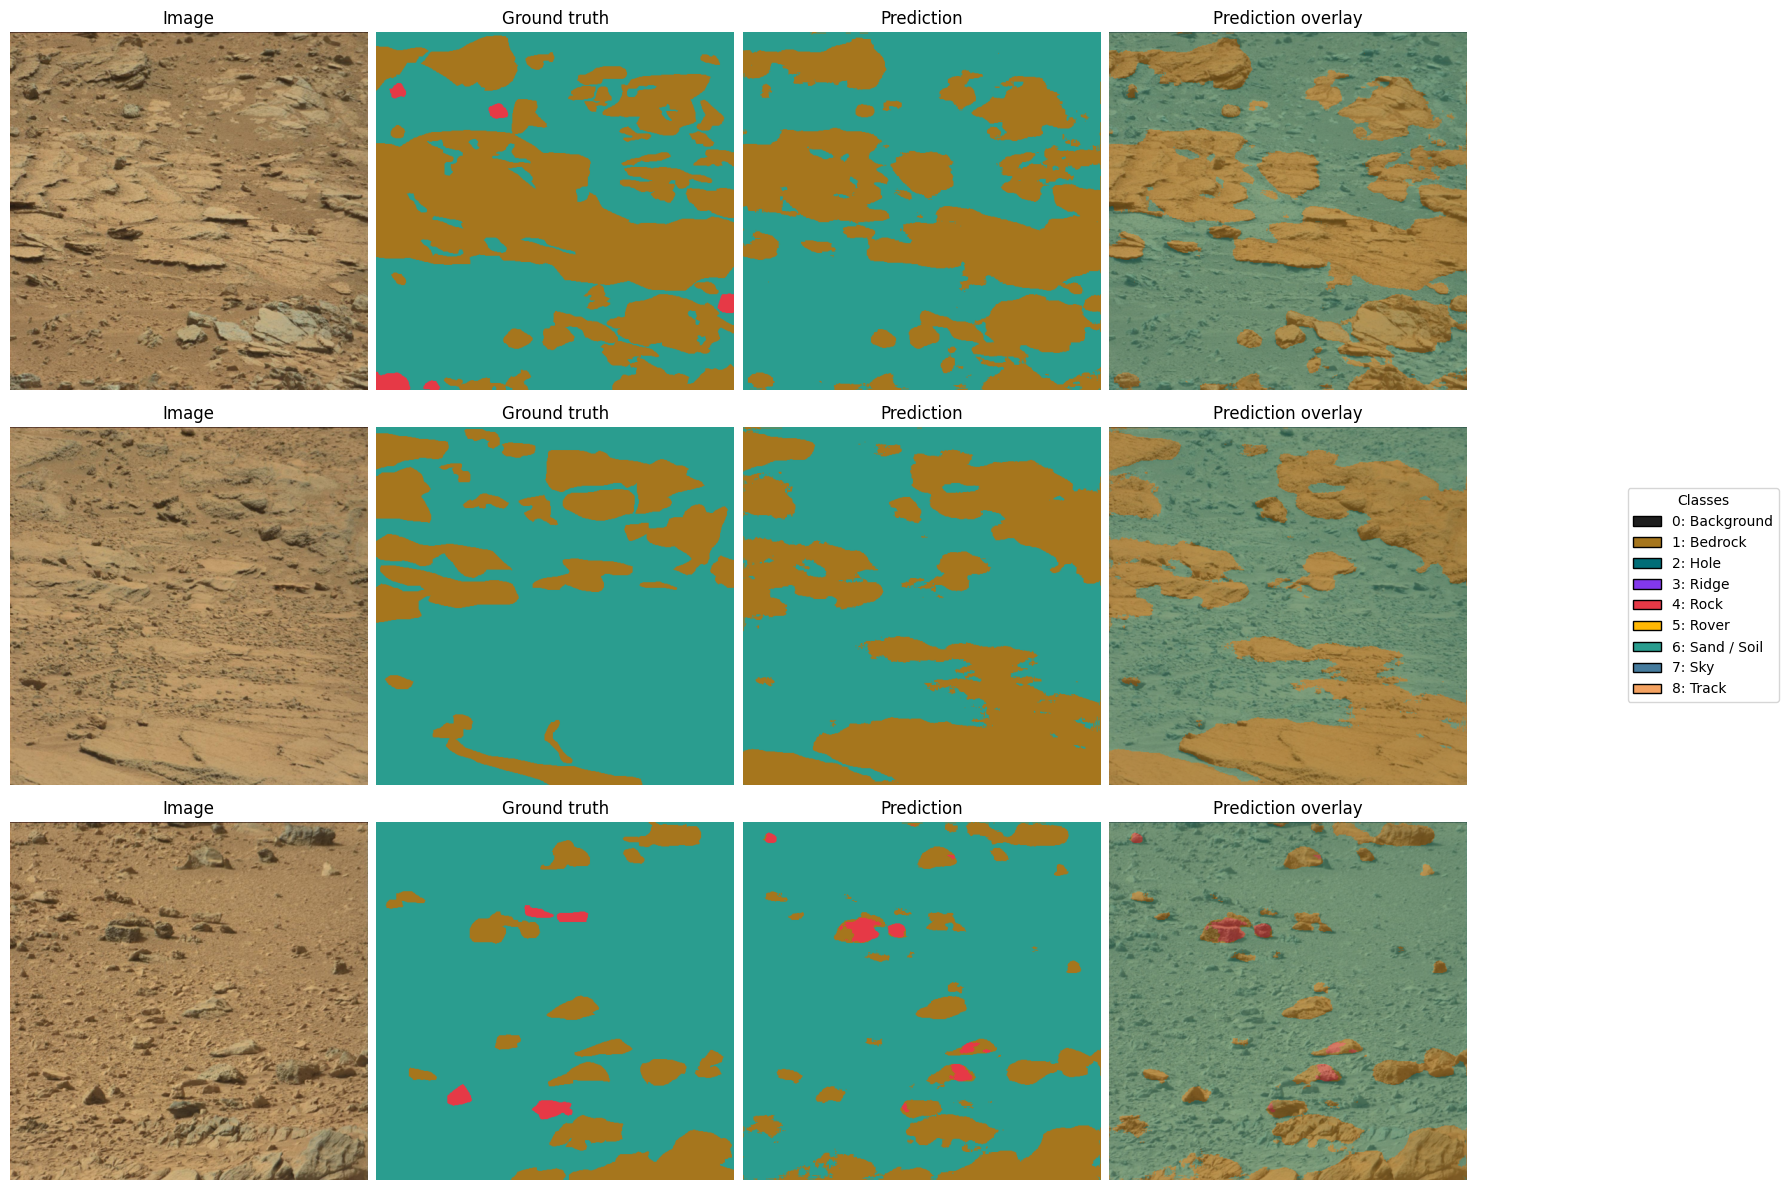

Saved predictions to /kaggle/working/unet_resnet34_s5mars/prediction_grid.png


In [95]:
@torch.no_grad()
def predict_sample(index, dataset):
    model.eval()
    sample = dataset[index]
    image = sample["image"].unsqueeze(0).to(device)
    logits = model(image)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu()
    return sample, pred

def plot_prediction(index, dataset, axis_row=None):
    sample, pred = predict_sample(index, dataset)
    image = denormalize(sample["image"])
    gt = colorize_mask(sample["mask"])
    pred_color = colorize_mask(pred)
    pred_overlay = overlay(image, pred_color)

    axes = axis_row
    if axes is None:
        fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, arr, title in zip(axes, [image, gt, pred_color, pred_overlay], ["Image", "Ground truth", "Prediction", "Prediction overlay"]):
        ax.imshow(arr)
        ax.set_title(title)
        ax.axis("off")

indices = list(range(min(3, len(test_dataset))))
fig, axes = plt.subplots(len(indices), 4, figsize=(18, 4 * len(indices)))
if len(indices) == 1:
    axes = np.expand_dims(axes, 0)
for row, index in enumerate(indices):
    plot_prediction(index, test_dataset, axes[row])
add_class_legend(fig)
fig.tight_layout(rect=(0, 0, 0.84, 1))
pred_path = Path(OUTPUT_DIR) / "prediction_grid.png"
fig.savefig(pred_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved predictions to {pred_path}")


In [96]:
print(f"Outputs written to {OUTPUT_DIR}")
print(sorted(path.name for path in Path(OUTPUT_DIR).glob("*")))


Outputs written to /kaggle/working/unet_resnet34_s5mars
['best.ckpt', 'history.json', 'last.ckpt', 'prediction_grid.png', 'test_metrics.json']


In [97]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [98]:
# del optimizer
#del model
#del scheduler

In [99]:
#del train_loader
#del val_loader
#del test_loader

In [100]:
a = 2
a = a + a
print(a)

4
